This notebook demonstrates the idea of gain calibration.
The time sequence is divided into N chunks and we model the gains within each chunk as a mean plus a coloured noise.
    The N parameters characterising the mean gain per chunk are independent.
    Different chunks have the same noise statistics, but are statistically independent.

In this notebook we try this strategy on a standard flicker noise and on an arbitrary noise whose high frequency PSD follows a power law.

In [1]:
import numpy as np
from scipy.fft import rfft, irfft, rfftfreq, fft, fftfreq
import matplotlib.pyplot as plt

## Functions for noise simulation

This function generates Gaussian random noise with arbitrary PSD.
(The DC mode is fixed to be zero. And it directly adds the mean value to the noise.)

In [3]:
def generate_colored_noise_1D(mean, psd, size):
    # Generate white noise with normal distribution
    white_noise = np.random.normal(0, 1, size)

    # Compute the FFT of the white noise
    fft_white = rfft(white_noise)

    
    # Apply the filter to the FFT of the white noise
    fft_colored = fft_white * np.sqrt(psd)

    # Compute the inverse FFT to obtain the colored noise
    colored_noise = irfft(fft_colored)

    return colored_noise + mean

Functions for the standard 1/f noise:

In [4]:
def flicker_noise_psd_1D(size, timestep, f0, alpha):
    freq = rfftfreq(size, timestep)
    #epsilon = 1e-12 / timestep**2
    result = np.zeros(len(freq))
    result[1:] = (f0 / freq[1:]) ** alpha
    return result

def generate_flicker_noise_1D(mean, size, timestep = 2, f0 = 0.1, alpha = 2.5):
    psd = flicker_noise_psd_1D(size, timestep, f0, alpha)
    return generate_colored_noise_1D(mean, psd, size)

Functions for a noise with a strange PSD: 
(But for large frequency modes, it approximates a power law.)

In [5]:
def strange_noise_psd_1D(size, timestep, f0, alpha):
    freq = rfftfreq(size, timestep)
    #epsilon = 1e-12 / timestep**2
    result = np.zeros(len(freq))
    result[1:] = (f0 / freq[1:]) ** alpha
    window = np.hanning(4)
    result[1:5] = result[1:5] * window
    return result

def generate_strange_noise_1D(mean, size, timestep = 2, f0 = 0.1, alpha = 2.5):
    psd = strange_noise_psd_1D(size, timestep, f0, alpha)
    return generate_colored_noise_1D(mean, psd, size)

Function for computing the PSD:

In [6]:
def calculate_power_spectrum_1D(data, timestep):
    size = len(data)
    freq = rfftfreq(size, timestep)
    fft_data = rfft(data)
    return freq, np.abs(fft_data) ** 2

## Functions for maximum likelihood solution and the sampler

In [7]:
def flicker_noise_time_covariance(size, timestep, f0, alpha):
    """"
    Generate the time covariance matrix for flicker noise.
    """
    freq = np.abs(fftfreq(size, timestep))
    
    xv, yv = np.meshgrid(np.arange(size), np.arange(size))
    diff_matrix = yv - xv

    result = 0
    
    for n in range(1, size):
        cos_term = np.cos(diff_matrix * 2 * np.pi * n / size)
        freq_term = (f0  / freq[n] ) ** alpha 
        result += cos_term * freq_term
    
    return result / size

In [8]:
def mean_gains_linear_solver(per_chunk_N_mat, full_gain_vec):
    """
    Sampling per-chunk mean gains using a linear solver.
    """
    chunk_size = len(per_chunk_N_mat)
    n_chunks = int(len(full_gain_vec)/chunk_size)
    N_inv = np.linalg.inv(per_chunk_N_mat)
    diag_mat = np.sum(N_inv) * np.ones(n_chunks)
    Amatrix = np.diag(diag_mat)

    gain_array = full_gain_vec.reshape((n_chunks, chunk_size))
    qVector = np.einsum('ij,aj->a', N_inv, gain_array)

    Lmatr = np.linalg.cholesky(Amatrix)
    bVector = qVector + Lmatr@np.random.normal(0, 1, n_chunks)
    result = np.linalg.solve(Amatrix, bVector)
    return result


def mean_gains_ML_solution(per_chunk_N_mat, full_gain_vec):
    """
    Solve for the maximum likelihood mean gains using the linear solver.
    """
    chunk_size = len(per_chunk_N_mat)
    n_chunks = int(len(full_gain_vec)/chunk_size)
    N_inv = np.linalg.inv(per_chunk_N_mat)
    diag_mat = np.sum(N_inv) * np.ones(n_chunks)
    Amatrix = np.diag(diag_mat)

    gain_array = full_gain_vec.reshape((n_chunks, chunk_size))
    qVector = np.einsum('ij,aj->a', N_inv, gain_array)

    result = np.linalg.solve(Amatrix, qVector)
    return result

## Simulation

In [9]:
num = 1800
fknee = 0.1 # Hz
dt = 2 # s
dnu = 1000000 # Hz
alpha = 2.5
mean = 300

times = np.arange(0, num*dt, dt) # One hour of data

num_chunks = 30
chunk_size = int(num/num_chunks)
noise_cov_per_chunk = flicker_noise_time_covariance(chunk_size, dt, fknee, alpha)


### Flicker noise

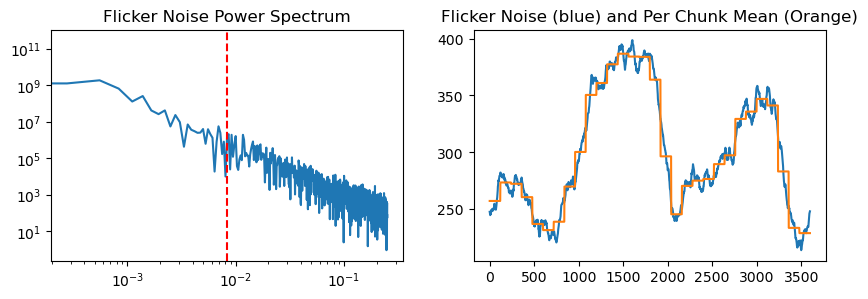

In [10]:
flicker_noise = generate_flicker_noise_1D(mean, num, dt, fknee, alpha)
mean_gains = mean_gains_ML_solution(noise_cov_per_chunk, flicker_noise)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

fft_freqs, psd = calculate_power_spectrum_1D(flicker_noise, dt)
axs[0].loglog(fft_freqs, psd)
axs[0].axvline(x=1/(chunk_size*dt), color='r', linestyle='--')
axs[0].title.set_text('Flicker Noise Power Spectrum')
axs[1].plot(times, flicker_noise)
axs[1].plot(times, np.repeat(mean_gains, chunk_size))
axs[1].title.set_text('Flicker Noise (blue) and Per Chunk Mean (Orange)')

### Strange noise but has power-law behavior at high frequencies.

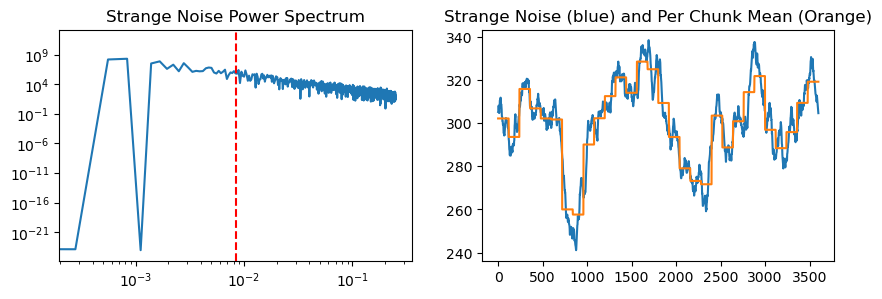

In [11]:
strange_noise = generate_strange_noise_1D(mean, num, dt, fknee, alpha)
mean_gains = mean_gains_ML_solution(noise_cov_per_chunk, strange_noise)


fig, axs = plt.subplots(1, 2, figsize=(10, 3))

fft_freqs, psd = calculate_power_spectrum_1D(strange_noise, dt)
axs[0].loglog(fft_freqs, psd)
axs[0].axvline(x=1/(chunk_size*dt), color='r', linestyle='--')
axs[0].title.set_text('Strange Noise Power Spectrum')
axs[1].plot(times, strange_noise)
axs[1].plot(times, np.repeat(mean_gains, chunk_size))
axs[1].title.set_text('Strange Noise (blue) and Per Chunk Mean (Orange)')

In [24]:
def chunk_data(data, gap):
    # Initialize an empty list to hold the chunks
    chunks = []
    indices = []
    
    counter = 0
    
    # Loop until all data is processed
    while data:
        start_value = data[0]

        # Calculate the start and end range for the current chunk
        chunk_start = start_value
        chunk_end = start_value + gap
        
        # Create a chunk by including all elements in the range [chunk_start, chunk_end)
        chunk = [x for x in data if chunk_start <= x < chunk_end]
        # Find the corresponding indices for the chunk elements
        chunk_length = len(chunk)
        chunk_indices = [x + counter for x in range(chunk_length)] 
        counter += chunk_length
        
        # Append the chunk to the result
        chunks.append(chunk)

        # Append the indices to the result
        indices.append(chunk_indices)
        
        # Remove the used elements from data
        data = [x for x in data if x >= chunk_end]
        
    return chunks, indices

In [26]:
import numpy as np

def sample_from_multiple_distributions(b_values, std_dev_values):
    # Convert b_values and std_dev_values to numpy arrays if they are not already
    b_values = np.array(b_values)
    std_dev_values = np.array(std_dev_values)
    
    # Generate one sample for each pair of b and std_dev using vectorized numpy.random.normal
    samples = np.random.normal(loc=b_values, scale=std_dev_values)
    
    return samples

# Example usage
b_values = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]  # List of means (b)
std_dev_values = [0.5, 1.0, 1.5, 0.3, 0.7, 0.9]  # List of standard deviations (std_dev)

samples = sample_from_multiple_distributions(b_values, std_dev_values)
print(samples)

[0.17227098 1.69757786 3.00093378 3.03531887 3.55062347 4.96912098]


In [9]:
data

[1, 2, 3, 7, 8, 15, 16, 17, 22]